# Part 3: CNN classifier on LFW faces (PyTorch)

Same dataset as Part 2, but instead of PCA + random forest we learn the features
directly with a small convolutional network.

Architecture: 2 conv layers (3x3 kernel, 32 filters each) -> dense layers -> 7 classes.
Adam optimiser, sparse categorical cross entropy loss.

Baseline to beat: Part 2's random forest on eigenfaces = 0.606 accuracy.

In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
torch.manual_seed(42)

device: cpu


In [5]:
# Reload + re-split, not reusing Part 2's X_train/X_test (part 2 was mean-centered)
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

n_samples, h, w = lfw_people.images.shape   # 1288, 50, 37
X = lfw_people.data                          # (1288, 1850) float32
y = lfw_people.target                        # (1288,) int64, values 0..6
target_names = lfw_people.target_names
n_classes = target_names.shape[0]            # 7

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(X_train.shape, X_test.shape, h, w, n_classes)


(966, 1850) (322, 1850) 50 37 7


## Reshaping for conv layers

Part 2 used the flattened form `(n_samples, 1850)` because the random forest ignores
pixel positions. A CNN needs the spatial layout back, in PyTorch's NCHW order:

    (batch, channels, height, width)

These are greyscale faces, so channels = 1.

X_train min: 0.0 max: 1.0
X_train_img shape: (966, 1, 50, 37)
X_test_img shape: (322, 1, 50, 37)


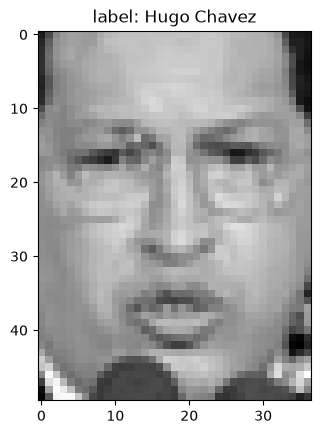

In [6]:
# --- Reshape + normalize ---

print("X_train min:", X_train.min(), "max:", X_train.max())

X_train_img = X_train.reshape(-1, 1, h, w)
X_test_img = X_test.reshape(-1, 1, h, w)

print("X_train_img shape:", X_train_img.shape)
print("X_test_img shape:", X_test_img.shape)

import matplotlib.pyplot as plt
plt.imshow(X_train_img[0, 0], cmap='gray')
plt.title(f'label: {target_names[y_train[0]]}')
plt.show()

In [8]:
# --- NumPy -> torch tensors, wrapped in DataLoaders ---

# convert the image arrays to float32 torch tensors.
X_train_t = torch.tensor(X_train_img, dtype = torch.float32)
X_test_t  = torch.tensor(X_test_img, dtype = torch.float32)

# convert the labels to torch tensors of INTEGER class indices.
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# wrap each (X, y) pair in a dataset, then a loader.
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

torch.Size([32, 1, 50, 37]) torch.Size([32])


## Model architecture

Two conv layers, 3x3 kernel, 32 filters each, then dense layers to 7 classes.

Work out your own shapes with the conv output formula:

    out = floor((in + 2*padding - kernel) / stride) + 1

One valid configuration (padding=1, stride=1, 2x2 max-pool after each conv):

| stage            | shape              |
|------------------|--------------------|
| input            | (B, 1, 50, 37)     |
| conv1 + ReLU     | (B, 32, 50, 37)    |
| maxpool 2x2      | (B, 32, 25, 18)    |
| conv2 + ReLU     | (B, 32, 25, 18)    |
| maxpool 2x2      | (B, 32, 12, 9)     |
| flatten          | (B, 3456)          |
| dense + ReLU     | (B, 128)           |
| dense (output)   | (B, 7)             |

3456 = 32 * 12 * 9. If you change padding or pooling, recompute this -- it's the
number the first dense layer needs.


In [12]:
class FaceCNN(nn.Module):
    """Small CNN: 2 conv layers (3x3, 32 filters) -> dense -> n_classes.

    Outputs raw LOGITS of shape (batch, n_classes) -- no softmax here, because
    the loss function applies it internally.
    """

    def __init__(self, n_classes, h=50, w=37):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)  # halves h and w each time it's used

        # h,w shrink by half at each pool: 50->25->12, 37->18->9
        flat_h = h // 2 // 2
        flat_w = w // 2 // 2
        flat_features = 32 * flat_h * flat_w  # 32*12*9 = 3456

        self.fc1 = nn.Linear(flat_features, 128)
        self.fc2 = nn.Linear(128, n_classes)
        self.dropout = nn.Dropout(0.3)  # optional -- helps since 966 images isn't much data

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> (B, 32, 25, 18)
        x = self.pool(F.relu(self.conv2(x)))   # -> (B, 32, 12, 9)
        x = torch.flatten(x, start_dim=1)      # -> (B, 3456)
        x = F.relu(self.fc1(x))                # -> (B, 128)
        x = self.dropout(x)
        x = self.fc2(x)                        # -> (B, n_classes), raw logits, no softmax
        return x


No padding: kernel only visits positios where it fully fits inside the image, so edge positions get skipped
Padding = 1: kernel can center itself on every original pixel (same padding)

In [13]:
# --- Instantiate, loss, optimizer ---

model = FaceCNN(n_classes=n_classes, h=h, w=w).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Trainable parameters: {n_params}")

FaceCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3456, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=7, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
Trainable parameters: 452967


epoch 1/20  loss 1.7478  acc 0.3975
epoch 2/20  loss 1.7073  acc 0.4120
epoch 3/20  loss 1.6684  acc 0.4172
epoch 4/20  loss 1.5527  acc 0.4524
epoch 5/20  loss 1.3929  acc 0.4959
epoch 6/20  loss 1.2602  acc 0.5393
epoch 7/20  loss 1.0682  acc 0.6170
epoch 8/20  loss 0.9437  acc 0.6511
epoch 9/20  loss 0.8246  acc 0.7029
epoch 10/20  loss 0.7244  acc 0.7474
epoch 11/20  loss 0.6356  acc 0.7816
epoch 12/20  loss 0.5398  acc 0.8157
epoch 13/20  loss 0.5048  acc 0.8230
epoch 14/20  loss 0.4492  acc 0.8489
epoch 15/20  loss 0.3752  acc 0.8696
epoch 16/20  loss 0.3639  acc 0.8778
epoch 17/20  loss 0.3331  acc 0.8913
epoch 18/20  loss 0.2807  acc 0.9058
epoch 19/20  loss 0.2469  acc 0.9141
epoch 20/20  loss 0.2268  acc 0.9317


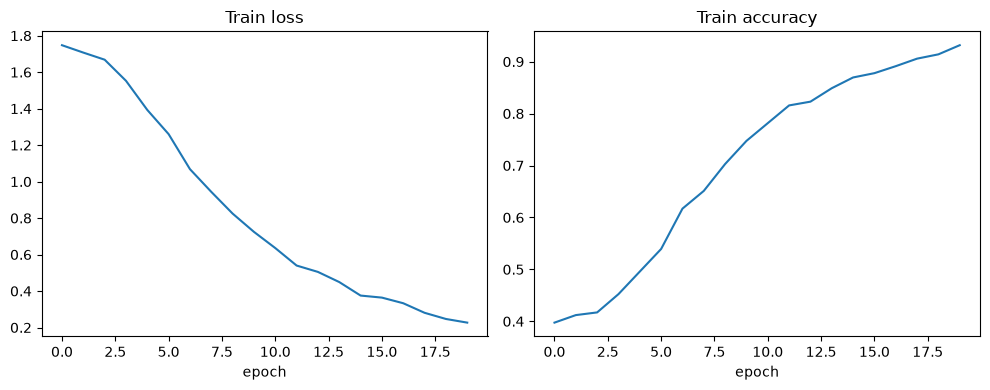

In [14]:
# --- Training loop ---

EPOCHS = 20  # tune this

train_loss_history = []
train_acc_history = []

for epoch in range(EPOCHS):
    model.train()

    epoch_loss = 0.0
    n_correct = 0
    n_seen = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        n_correct += (preds == yb).sum().item()
        n_seen += xb.size(0)

    epoch_avg_loss = epoch_loss / n_seen
    epoch_acc = n_correct / n_seen
    train_loss_history.append(epoch_avg_loss)
    train_acc_history.append(epoch_acc)
    print(f"epoch {epoch+1}/{EPOCHS}  loss {epoch_avg_loss:.4f}  acc {epoch_acc:.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history)
plt.title('Train loss')
plt.xlabel('epoch')

plt.subplot(1, 2, 2)
plt.plot(train_acc_history)
plt.title('Train accuracy')
plt.xlabel('epoch')
plt.tight_layout()
plt.show()

In [15]:
# --- Evaluation on the test set ---

model.eval()

all_preds = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.cpu())

all_preds = torch.cat(all_preds).numpy()

test_acc = (all_preds == y_test).mean()
print("CNN test accuracy:", test_acc)
print("Part 2 random forest baseline: 0.606")

print(classification_report(y_test, all_preds, target_names=target_names))

CNN test accuracy: 0.8571428571428571
Part 2 random forest baseline: 0.606
                   precision    recall  f1-score   support

     Ariel Sharon       0.64      0.74      0.68        19
     Colin Powell       0.92      0.93      0.92        59
  Donald Rumsfeld       0.86      0.60      0.71        30
    George W Bush       0.88      0.95      0.92       133
Gerhard Schroeder       0.73      0.70      0.72        27
      Hugo Chavez       0.77      0.94      0.85        18
       Tony Blair       0.96      0.72      0.83        36

         accuracy                           0.86       322
        macro avg       0.82      0.80      0.80       322
     weighted avg       0.86      0.86      0.85       322



## Part 3 results & comparison

- CNN test accuracy: ___  vs  Part 2 random forest on eigenfaces: 0.606
- Which classes improved? (Part 2 scored 0.00 on Ariel Sharon -- 13 test samples.)
- The class imbalance is severe: George W Bush has 146 of 322 test samples, so
  always predicting him alone gives ~0.45. Check the CNN isn't doing that.
- Notes on overfitting: 966 training images, 7 classes. Did train accuracy pull
  far ahead of test accuracy? What did dropout / fewer epochs change?
Two things worth flagging as you fill it in:

TODO 28 (zero_grad) — omitting it is the classic silent bug. Loss will look weird rather than error out.
TODO 21 / TODO 19 must agree — if you apply softmax in forward and use the logits-based loss, you'll be double-softmaxing and the model will train badly but not crash.